# Qualification and Scholarship Grant Metrics

This notebook compares all applicants, remote applicants, and center applicants using one qualification formula. The proxy score is `(3 * R-score + 0.5 * income-need score + 0.5 * work-hours score) / 4`; the top 40% of scores qualify (60th percentile cutoff).

Metrics: **qualified / all applicants in group**; **granted / qualified applicants**; and **granted / unqualified applicants**. These are separate rates with different denominators. The grant decision is the historical `decision_octroi` label.

Qualification cutoff: 0.5496
        % qualified / all  % granted / qualified  % granted / unqualified
group                                                                    
All                 40.00                  78.55                    14.20
remote              41.38                  61.09                     3.45
center              39.08                  90.87                    21.09


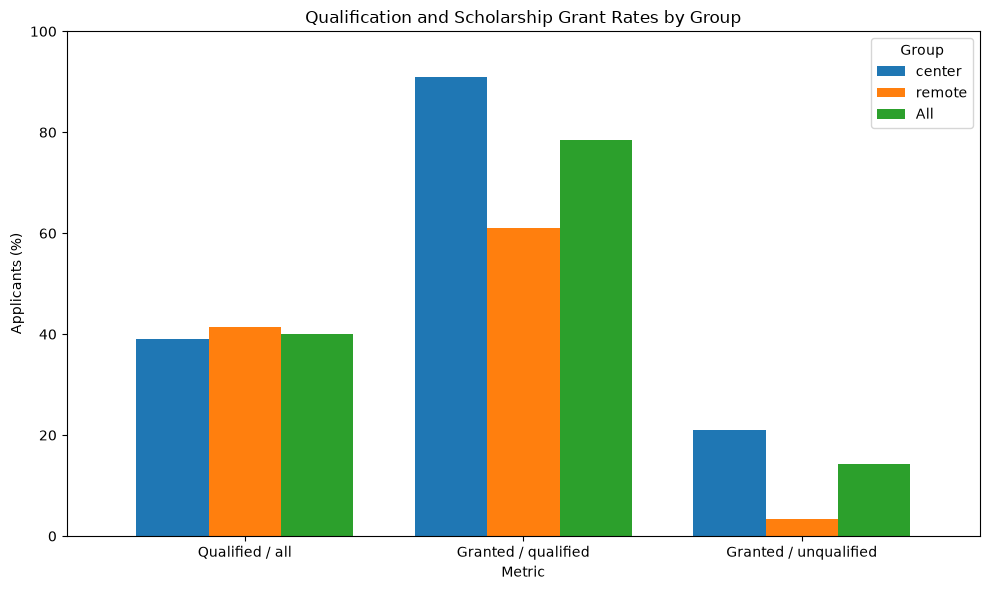

Saved table: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/Analysis/qualification_metrics.csv
Saved chart: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/Analysis/qualification_metrics.png


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

raw_relative_path = Path("equialgo-participants/data/donnees_demandes.csv")
repository_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / raw_relative_path).is_file()),
    None,
)
if repository_root is None:
    raise FileNotFoundError(f"Could not locate {raw_relative_path} from {Path.cwd()}")

analysis_dir = repository_root / "Analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(repository_root / raw_relative_path)

remote_regions = {"Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine"}
df["region_group"] = df["region_administrative"].apply(
    lambda region: "remote" if region in remote_regions else "center"
)

def minmax_scale(values):
    value_range = values.max() - values.min()
    if value_range == 0:
        return pd.Series(0.5, index=values.index)
    return (values - values.min()) / value_range

r_score = minmax_scale(df["cote_r_equivalent"])
income_need_score = 1 - minmax_scale(df["revenu_familial_estime"])
work_hours_score = minmax_scale(df["heures_travail_semaine"])
df["proxy_quality_score"] = (3 * r_score + 0.5 * income_need_score + 0.5 * work_hours_score) / 4
cutoff = df["proxy_quality_score"].quantile(0.60)
df["qualified_proxy"] = (df["proxy_quality_score"] >= cutoff).astype(int)

rows = []
for group_name in ["All", "remote", "center"]:
    group = df if group_name == "All" else df[df["region_group"] == group_name]
    qualified = group["qualified_proxy"] == 1
    unqualified = ~qualified
    rows.append(
        {
            "group": group_name,
            "% qualified / all": 100 * qualified.mean(),
            "% granted / qualified": 100 * group.loc[qualified, "decision_octroi"].mean(),
            "% granted / unqualified": 100 * group.loc[unqualified, "decision_octroi"].mean(),
        }
    )

table = pd.DataFrame(rows).set_index("group").round(2)
print(f"Qualification cutoff: {cutoff:.4f}")
print(table.to_string())
table.to_csv(analysis_dir / "qualification_metrics.csv", index=True, index_label="group")

plot_data = table.T[["center", "remote", "All"]].rename(
    index={
        "% qualified / all": "Qualified / all",
        "% granted / qualified": "Granted / qualified",
        "% granted / unqualified": "Granted / unqualified",
    }
)
ax = plot_data.plot(kind="bar", figsize=(10, 6), width=0.78)
ax.set_title("Qualification and Scholarship Grant Rates by Group")
ax.set_xlabel("Metric")
ax.set_ylabel("Applicants (%)")
ax.set_ylim(0, 100)
ax.legend(title="Group")
ax.tick_params(axis="x", rotation=0)
ax.figure.tight_layout()
chart_path = analysis_dir / "qualification_metrics.png"
ax.figure.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved table: {analysis_dir / 'qualification_metrics.csv'}")
print(f"Saved chart: {chart_path}")

## Short analysis

The proxy qualifies a similar share of remote and center applicants (41.38% vs. 39.08%). Among qualified applicants, 61.09% of remote applicants received a scholarship, compared with 90.87% of center applicants. Among unqualified applicants, the grant rates were 3.45% remote and 21.09% center. This is a substantial difference in historical decisions, but qualification is a constructed proxy, not an independently verified measure of eligibility.

## Grant rates across five R-score bands

Applicants are divided into five equal-sized bands by `cote_r_equivalent`. For each band, compare the historical scholarship grant rate for center and remote applicants.

Historical grant rate (%) by R-score band:
region_group  center  remote
r_band                      
1 lowest         0.7     0.1
2               10.9     2.7
3               37.5    12.8
4               79.6    50.5
5 highest       98.1    91.4


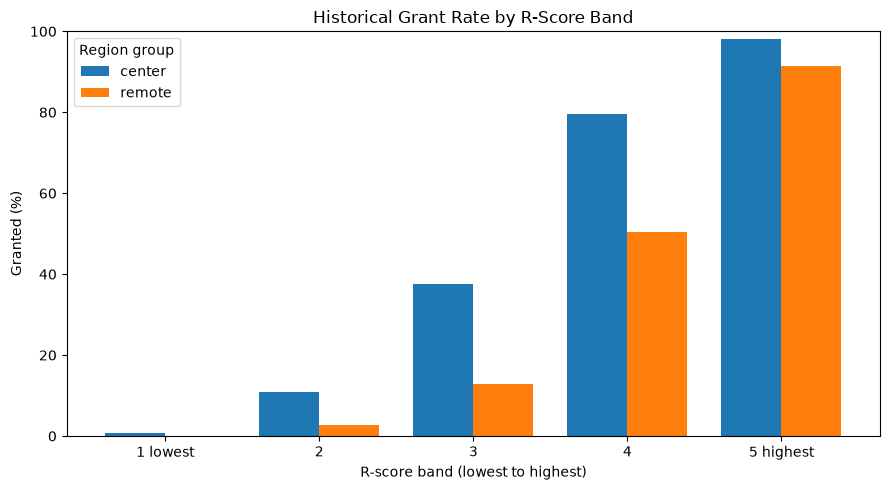

Saved table: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/Analysis/r_band_grant_rates.csv
Saved chart: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/Analysis/r_band_grant_rates.png


In [5]:
r_band_labels = ["1 lowest", "2", "3", "4", "5 highest"]
df["r_band"] = pd.qcut(df["cote_r_equivalent"], q=5, labels=r_band_labels)

r_band_table = (
    df.pivot_table(
        index="r_band",
        columns="region_group",
        values="decision_octroi",
        aggfunc="mean",
        observed=True,
    )
    .reindex(columns=["center", "remote"])
    .mul(100)
)

print("Historical grant rate (%) by R-score band:")
print(r_band_table.round(1).to_string())
r_band_table.round(2).to_csv(analysis_dir / "r_band_grant_rates.csv", index_label="r_band")

ax = r_band_table.plot(kind="bar", figsize=(9, 5), width=0.78)
ax.set_title("Historical Grant Rate by R-Score Band")
ax.set_xlabel("R-score band (lowest to highest)")
ax.set_ylabel("Granted (%)")
ax.set_ylim(0, 100)
ax.legend(title="Region group")
ax.tick_params(axis="x", rotation=0)
ax.figure.tight_layout()
r_band_chart_path = analysis_dir / "r_band_grant_rates.png"
ax.figure.savefig(r_band_chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved table: {analysis_dir / 'r_band_grant_rates.csv'}")
print(f"Saved chart: {r_band_chart_path}")